In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

import pickle

# Loading Dataset

In [6]:
df = pd.read_csv("/home/aryan/Desktop/Smart-Agriculture-Prediction-Platform/datasets/Fertilizer Prediction.csv")

In [7]:
df.head()

,Temperature,Humidity,Soil Moisture,Soil Type,Crop Type,Nitrogen,Potassium,Phosphorus,Fertilizer
0,29.89,69.58,27.33,Sandy Loam,Arhar/Tur,17.47,24.59,32.87,MOP
1,25.85,56.63,22.71,Sandy Loam,Arhar/Tur,3.76,17.32,27.77,20-40-20
2,25.30,50.72,22.73,Loamy,Arhar/Tur,4.48,18.11,28.25,20-40-20
3,29.45,46.51,41.87,Loamy,Arhar/Tur,4.85,12.62,43.49,MOP
4,16.02,56.99,48.91,Sand,Arhar/Tur,11.54,31.36,27.20,DAP


In [8]:
df.tail()



,Temperature,Humidity,Soil Moisture,Soil Type,Crop Type,Nitrogen,Potassium,Phosphorus,Fertilizer
8995,23.23,63.40,23.19,Sandy Loam,Wheat,116.28,37.17,37.51,MOP
8996,11.03,45.37,16.94,Clay Loam,Wheat,63.40,21.28,23.35,20-10-10
8997,18.84,61.50,20.55,Loamy,Wheat,88.88,30.37,34.17,DAP
8998,18.71,56.30,20.69,Clay Loam,Wheat,87.01,30.95,31.55,DAP
8999,34.02,81.48,20.69,Sand,Wheat,23.48,7.53,39.33,MOP


In [9]:
df.shape

(9000, 9)

# EDA

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9000 entries, 0 to 8999
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Temperature    9000 non-null   float64
 1   Humidity       9000 non-null   float64
 2   Soil Moisture  9000 non-null   float64
 3   Soil Type      9000 non-null   object 
 4   Crop Type      9000 non-null   object 
 5   Nitrogen       9000 non-null   float64
 6   Potassium      9000 non-null   float64
 7   Phosphorus     9000 non-null   float64
 8   Fertilizer     9000 non-null   object 
dtypes: float64(6), object(3)
memory usage: 632.9+ KB


In [11]:
df.isnull().sum()

Temperature      0
Humidity         0
Soil Moisture    0
Soil Type        0
Crop Type        0
Nitrogen         0
Potassium        0
Phosphorus       0
Fertilizer       0
dtype: int64

In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
print("Statistical Summary:")
display(df.describe())

Statistical Summary:


,Temperature,Humidity,Soil Moisture,Nitrogen,Potassium,Phosphorus
count,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000
mean,25.341906,56.823769,24.055993,47.404278,38.313750,33.762007
std,6.654133,13.983237,7.942876,49.113439,32.611419,13.754538
min,10.000000,30.020000,10.010000,-9.990000,5.010000,15.000000
25%,20.550000,46.047500,18.450000,7.910000,21.237500,23.290000
50%,25.820000,55.350000,22.370000,28.400000,27.320000,29.660000
75%,30.220000,66.062500,27.872500,76.070000,48.205000,41.462500
max,39.990000,90.000000,49.980000,249.750000,249.940000,79.760000


In [17]:
negative_nitrogen = df[df["Nitrogen"] < 0]

negative_nitrogen

,Temperature,Humidity,Soil Moisture,Soil Type,Crop Type,Nitrogen,Potassium,Phosphorus,Fertilizer
36,32.44,75.27,48.99,Sandy Loam,Arhar/Tur,-6.23,15.91,21.17,20-40-20
95,15.41,45.60,27.94,Loamy,Arhar/Tur,-4.24,28.73,41.57,20-40-20
104,23.55,32.68,31.27,Sandy Loam,Arhar/Tur,-7.75,26.22,33.12,MOP
125,27.15,79.83,17.31,Sandy Loam,Arhar/Tur,-8.79,28.66,16.59,MOP
156,30.43,52.36,48.55,Sandy Loam,Arhar/Tur,-5.59,12.80,23.27,MOP
...,...,...,...,...,...,...,...,...,...
8832,37.17,31.04,45.15,Sandy Loam,Wheat,-7.24,28.52,22.98,20-10-10
8847,18.71,35.43,46.08,Loamy,Wheat,-8.46,11.79,33.91,DAP
8862,31.52,61.66,26.84,Sandy Loam,Wheat,-1.86,32.93,19.15,MOP
8889,21.51,33.81,49.11,Clay,Wheat,-3.26,31.33,28.11,Urea


In [19]:
df = df[df["Nitrogen"] >= 0]

In [21]:
df = df.reset_index(drop=True)

In [22]:
df.shape

(8533, 9)

In [25]:
df.head()

,Temperature,Humidity,Soil Moisture,Soil Type,Crop Type,Nitrogen,Potassium,Phosphorus,Fertilizer
0,29.89,69.58,27.33,Sandy Loam,Arhar/Tur,17.47,24.59,32.87,MOP
1,25.85,56.63,22.71,Sandy Loam,Arhar/Tur,3.76,17.32,27.77,20-40-20
2,25.30,50.72,22.73,Loamy,Arhar/Tur,4.48,18.11,28.25,20-40-20
3,29.45,46.51,41.87,Loamy,Arhar/Tur,4.85,12.62,43.49,MOP
4,16.02,56.99,48.91,Sand,Arhar/Tur,11.54,31.36,27.20,DAP


In [27]:
print("Statistical Summary:")
display(df.describe())

Statistical Summary:


,Temperature,Humidity,Soil Moisture,Nitrogen,Potassium,Phosphorus
count,8533.000000,8533.000000,8533.000000,8533.000000,8533.000000,8533.000000
mean,25.212731,56.606432,23.709215,50.258941,39.283087,33.941827
std,6.604838,13.736427,7.546424,48.853394,33.159659,13.949259
min,10.000000,30.020000,10.010000,0.010000,5.010000,15.000000
25%,20.490000,46.080000,18.400000,9.500000,21.490000,23.310000
50%,25.760000,55.150000,22.200000,32.320000,27.730000,29.600000
75%,30.020000,65.620000,27.190000,80.090000,49.510000,41.830000
max,39.990000,90.000000,49.980000,249.750000,249.940000,79.760000


In [26]:
print("Categorical Summary:")
display(df.describe(include="object"))

Categorical Summary:


,Soil Type,Crop Type,Fertilizer
count,8533,8533,8533
unique,13,30,25
top,Sandy Loam,Safflower,MOP
freq,2681,289,2107


In [29]:
print("Fertilizer Count:")
print(df["Fertilizer"].value_counts())


Fertilizer Count:
Fertilizer
MOP                       2107
Urea                      1928
DAP                       1846
0-20-20                    489
40-20-20                   289
SSP                        210
20-20-20                   199
15-15-15                   198
20-10-10                   140
Organic compost            114
20-40-20                    94
20-30-20                    77
20-15-15                    77
25-10-15                    73
30-15-20                    73
0-40-40                     72
30-10-20                    71
30-20-20                    66
Compound NPK (0-20-20)      66
40-30-40                    60
20-10-20                    59
30-15-15                    58
120-60-60                   56
100-50-50                   56
60-40-60                    55
Name: count, dtype: int64


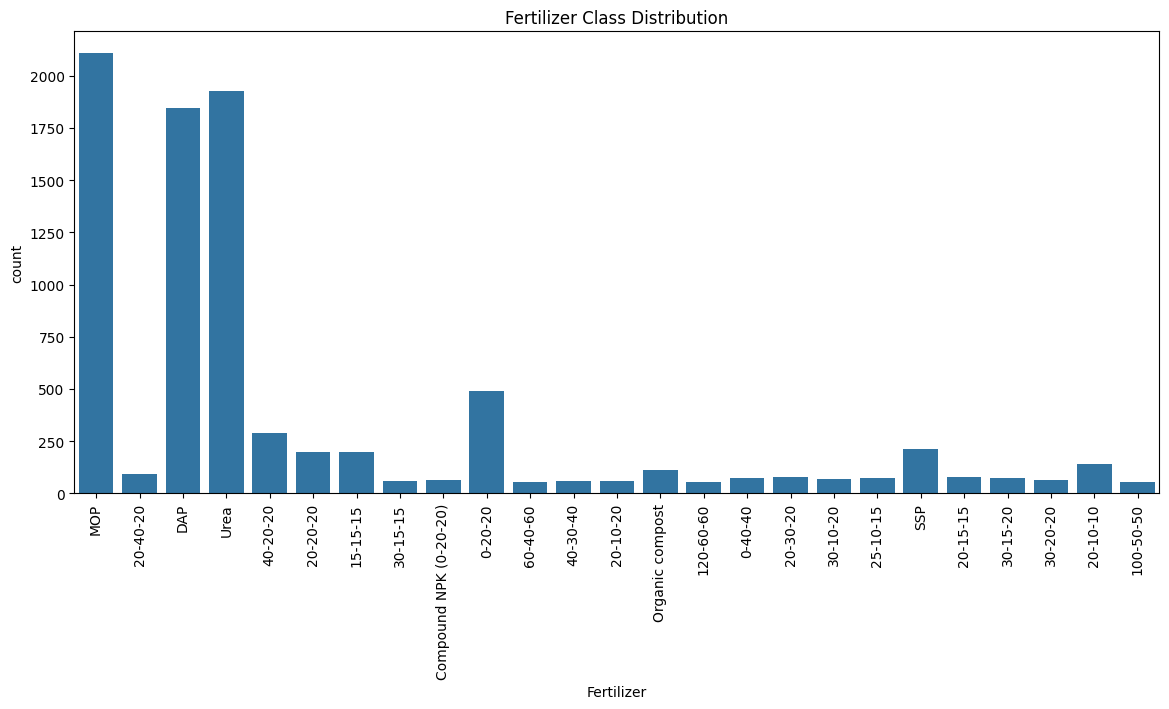

In [30]:
plt.figure(figsize=(14, 6))
sns.countplot(x="Fertilizer", data=df)
plt.xticks(rotation=90)
plt.title("Fertilizer Class Distribution")
plt.show()

In [31]:
print("Soil Type Count:")
print(df["Soil Type"].value_counts())

Soil Type Count:
Soil Type
Sandy Loam       2681
Loamy            2149
Clay Loam        1236
Red Loam          797
Loam              346
Clay              287
Sand              272
Sandy             256
Alluvial          155
Silty Loam        101
Red Clay Loam      96
Loamy Sand         93
Black Soil         64
Name: count, dtype: int64


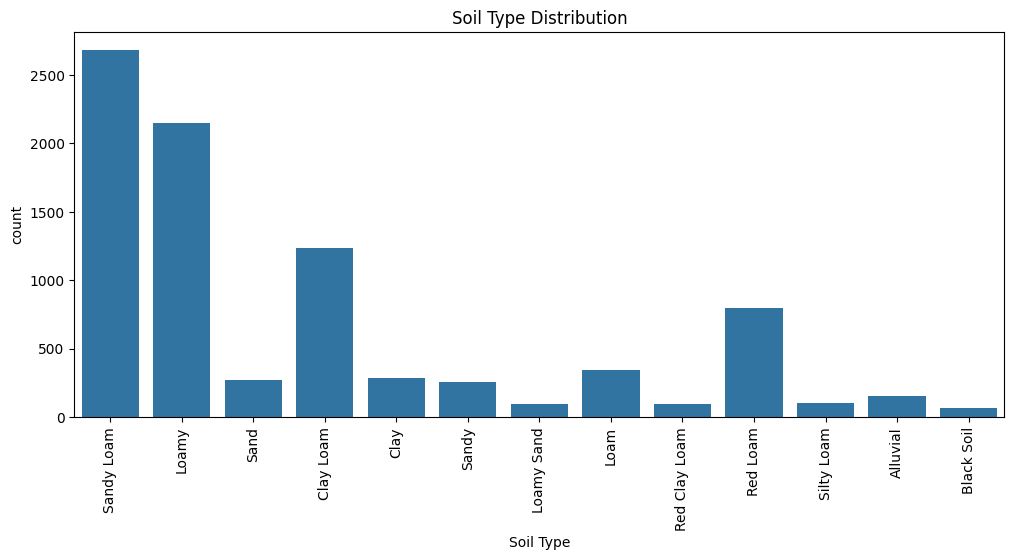

In [32]:
plt.figure(figsize=(12, 5))
sns.countplot(x="Soil Type", data=df)
plt.xticks(rotation=90)
plt.title("Soil Type Distribution")
plt.show()


In [33]:
print("Crop Type Count:")
print(df["Crop Type"].value_counts())

Crop Type Count:
Crop Type
Safflower                289
Urad Bean                289
Linseed (Flax)           288
Sunflower                288
Maize (Fodder)           287
Cotton (Lint)            287
Masoor (Red Lentil)      287
Urad (Black Gram)        287
Barley                   286
Rice                     286
Sugarcane                285
Coriander                285
Jowar                    285
Bajra                    285
Turmeric                 285
Moong (Green Gram)       284
Ragi (Finger Millet)     284
Wheat                    284
Groundnut                284
Gram (Chickpea)          284
Arhar/Tur                283
Dry Chillies             283
Peas & Beans (Pulses)    283
Garlic                   283
Maize (Grain)            282
Potato                   282
Onion                    281
Rapeseed & Mustard       280
Cowpea (Lobia)           279
Ginger                   278
Name: count, dtype: int64


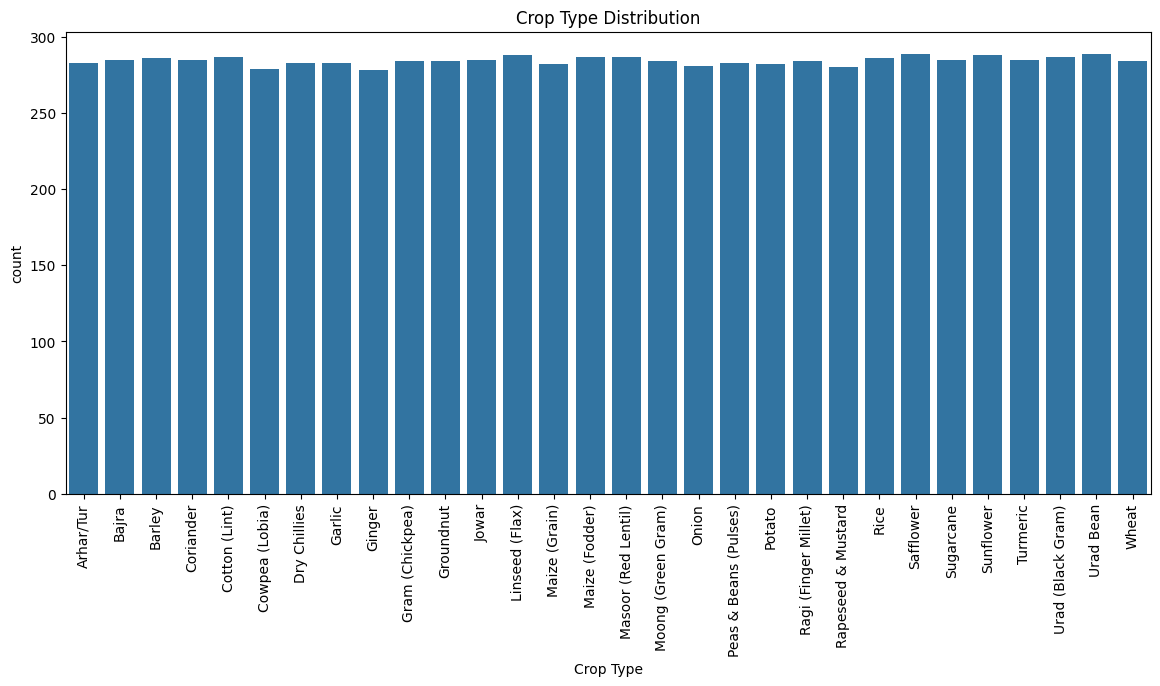

In [34]:

plt.figure(figsize=(14, 6))
sns.countplot(x="Crop Type", data=df)
plt.xticks(rotation=90)
plt.title("Crop Type Distribution")
plt.show()

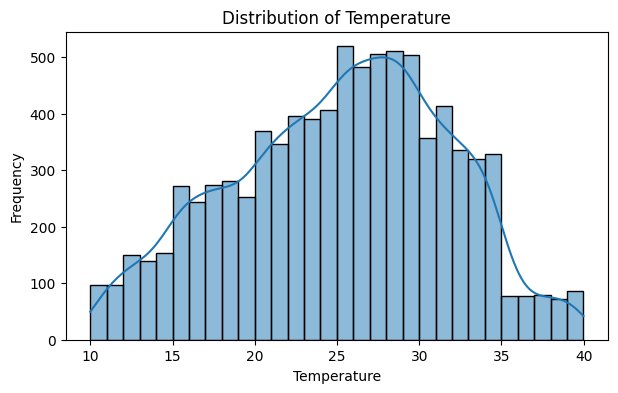

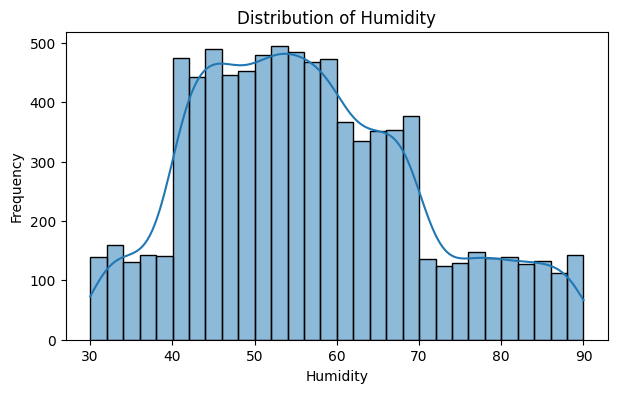

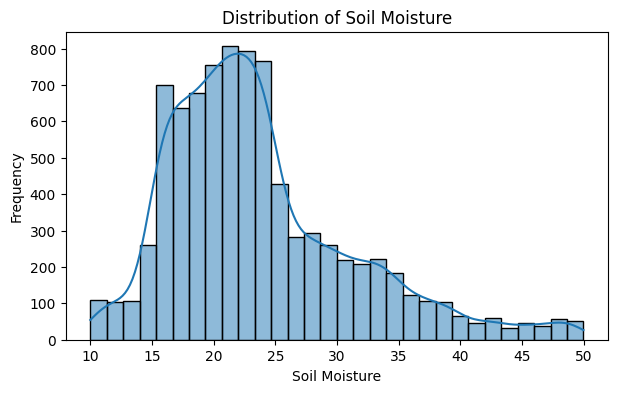

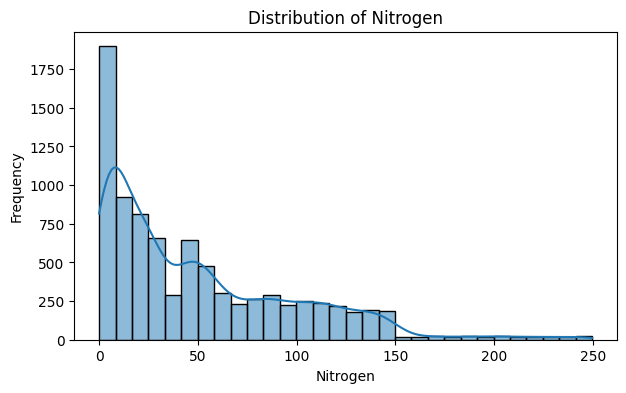

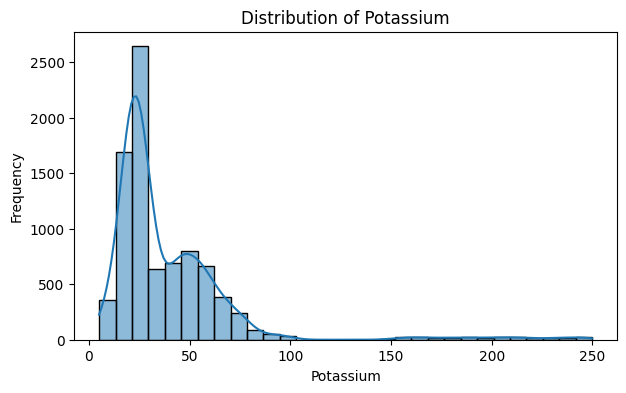

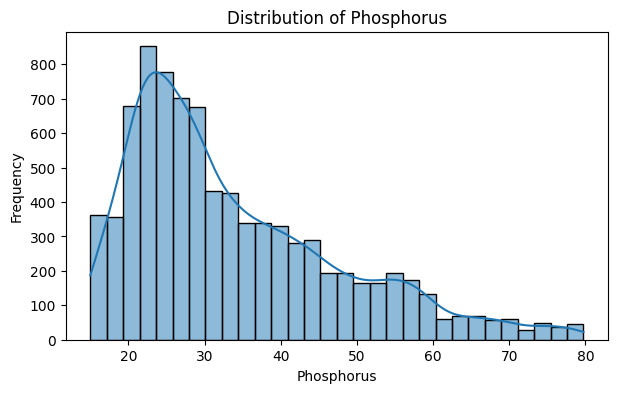

In [35]:
num_cols = [
    "Temperature",
    "Humidity",
    "Soil Moisture",
    "Nitrogen",
    "Potassium",
    "Phosphorus"
]

for col in num_cols:
    plt.figure(figsize=(7, 4))
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

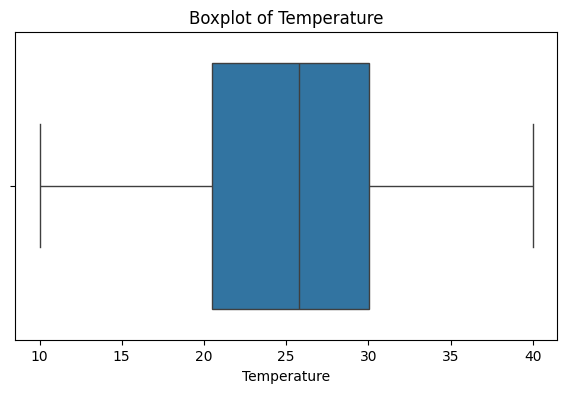

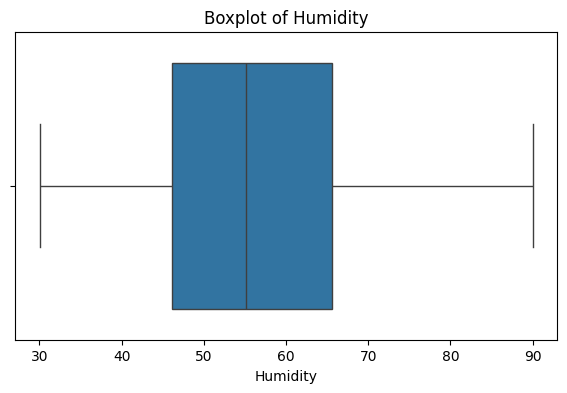

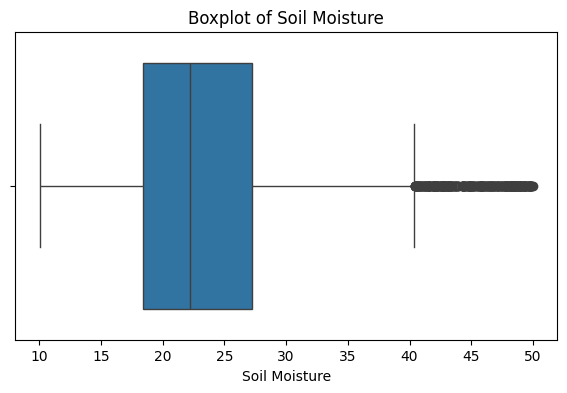

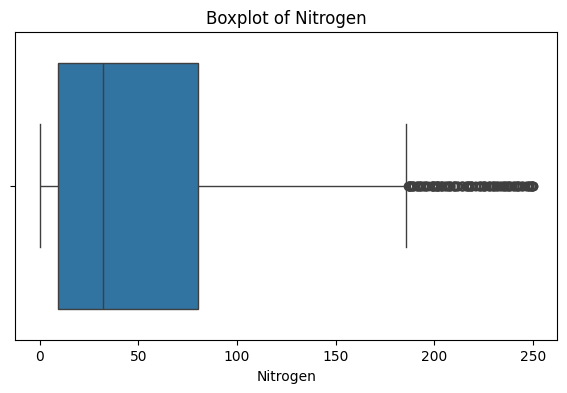

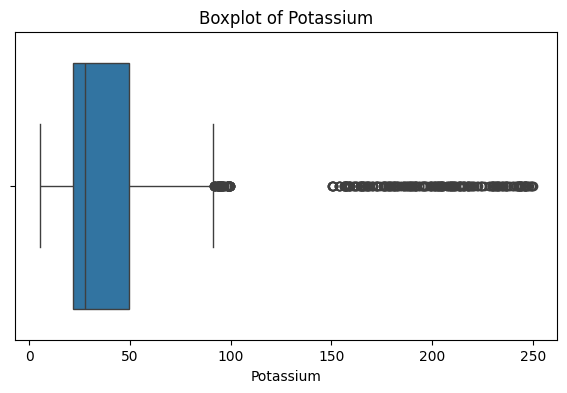

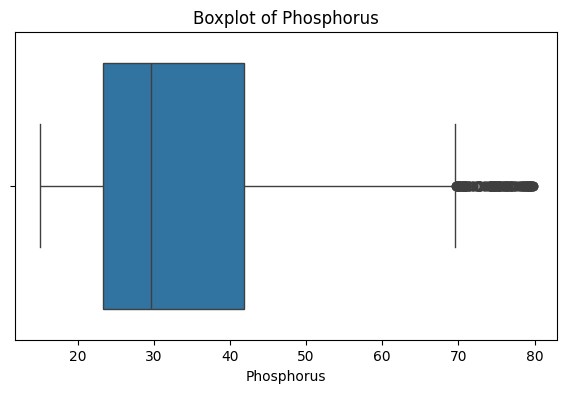

In [36]:
for col in num_cols:
    plt.figure(figsize=(7, 4))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)
    plt.show()

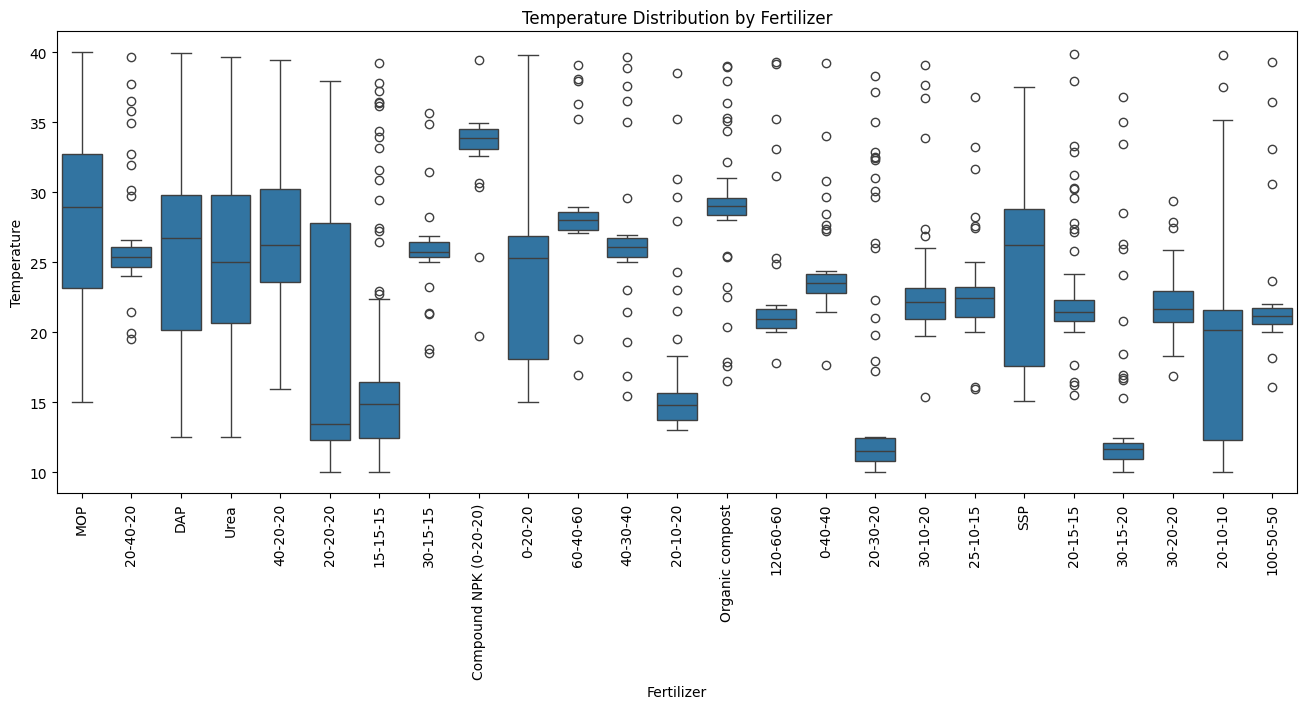

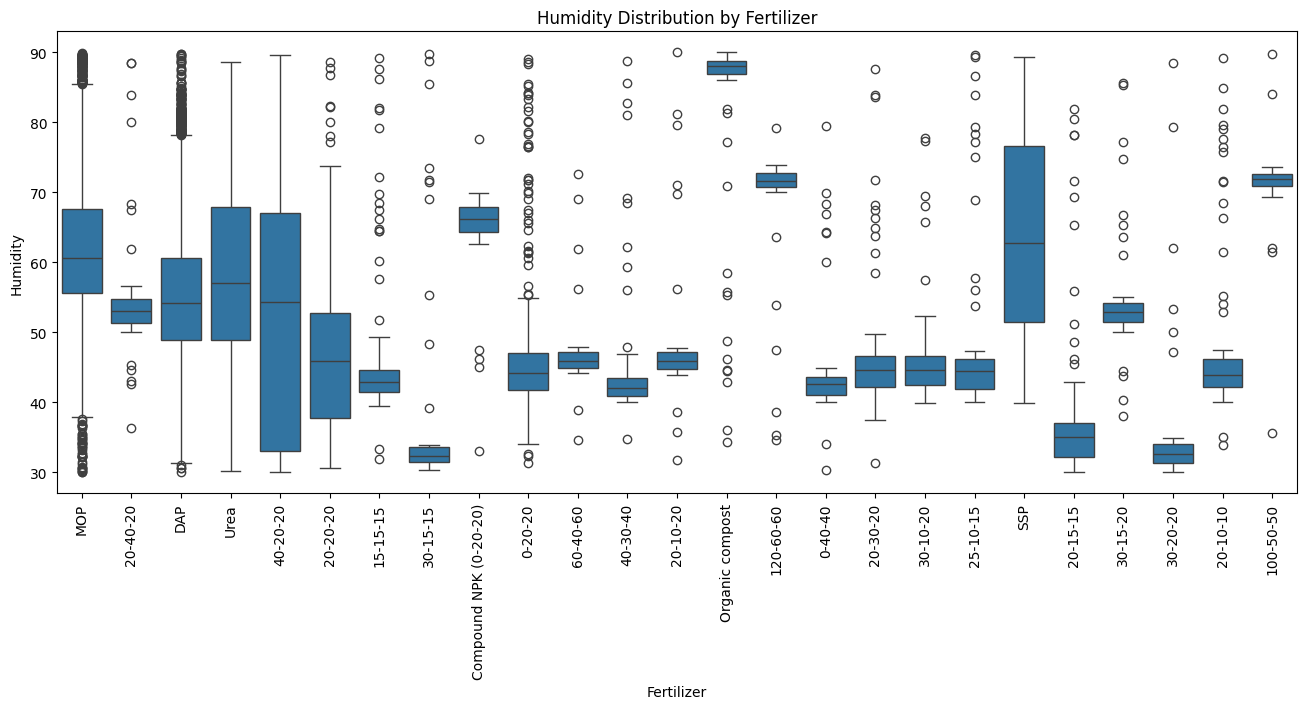

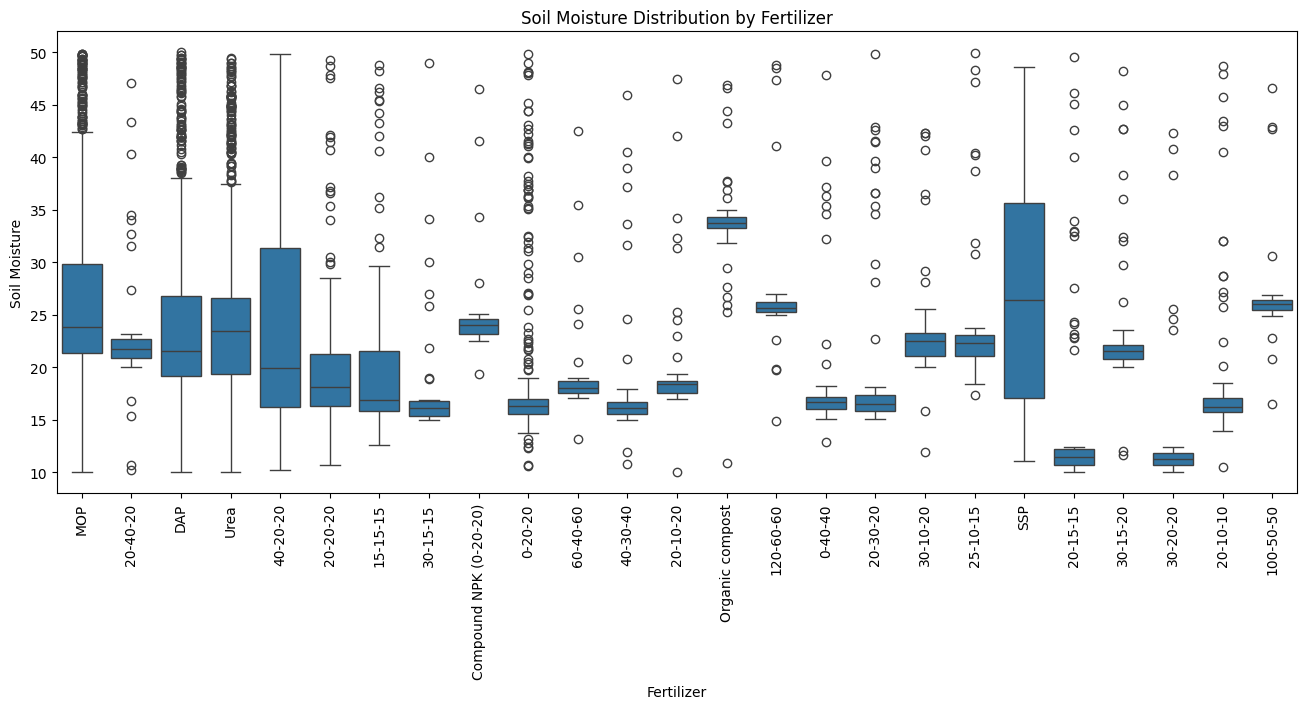

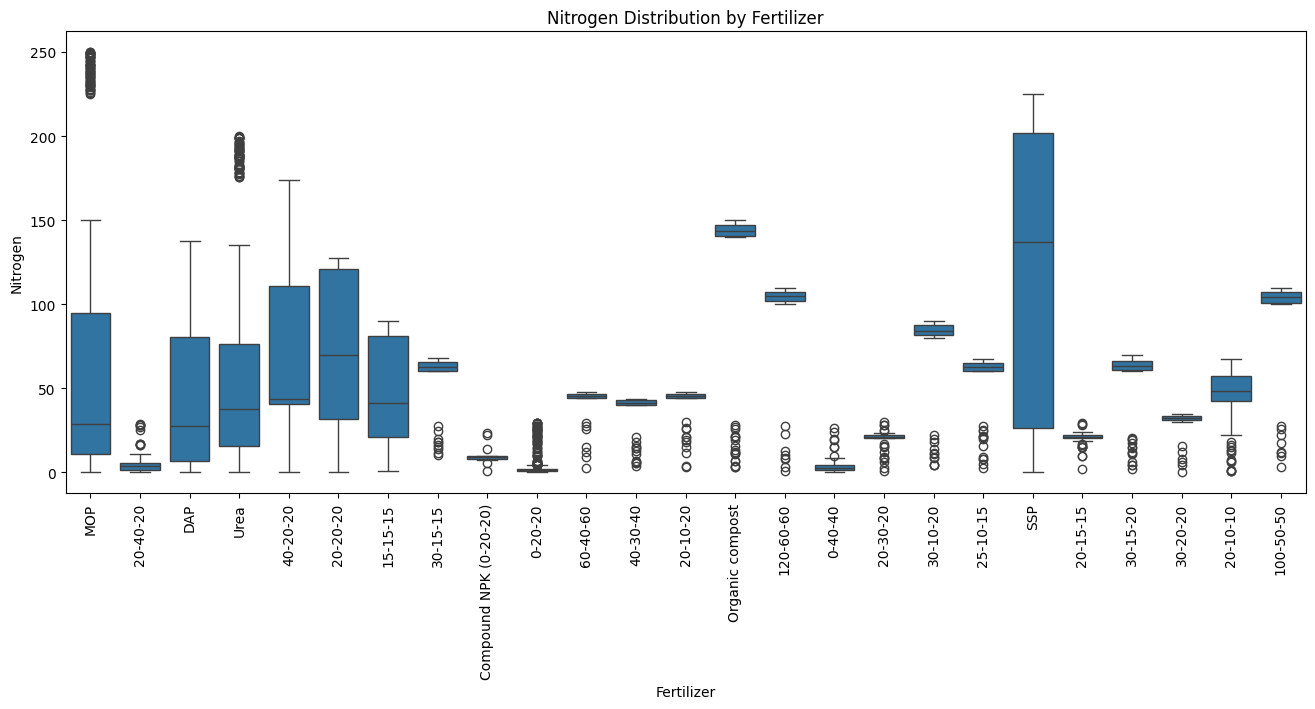

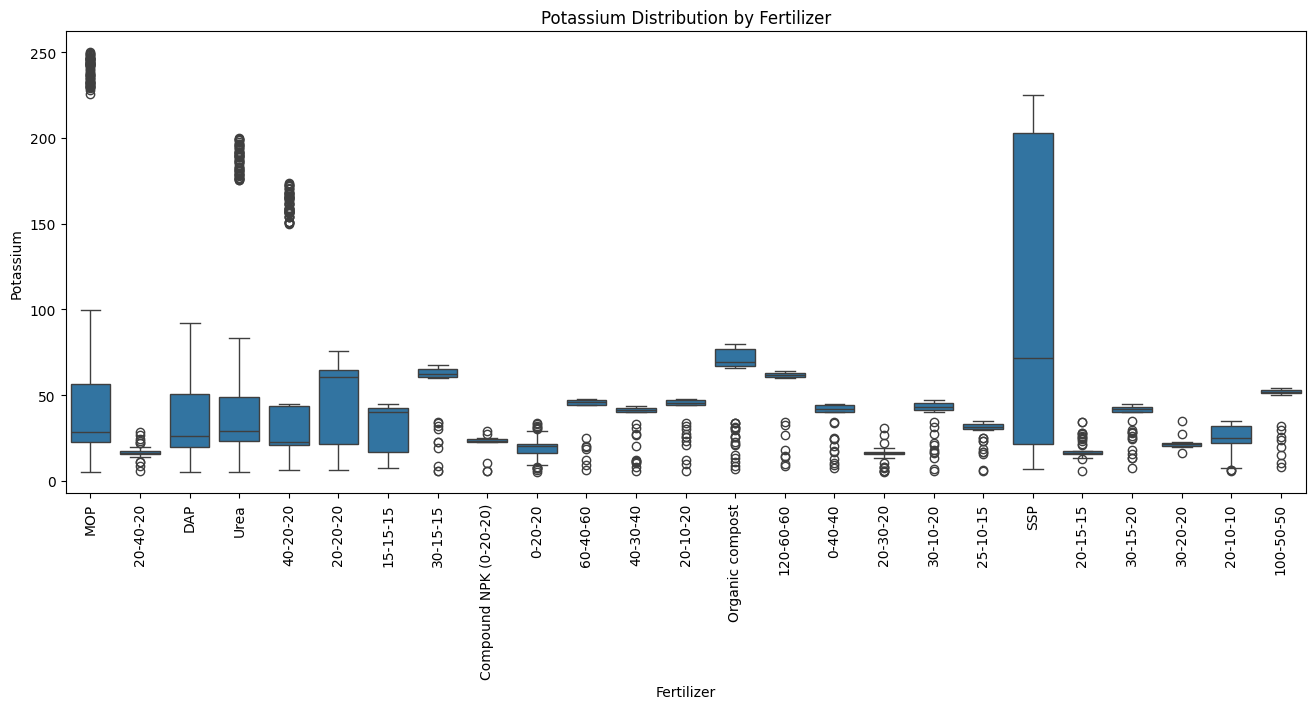

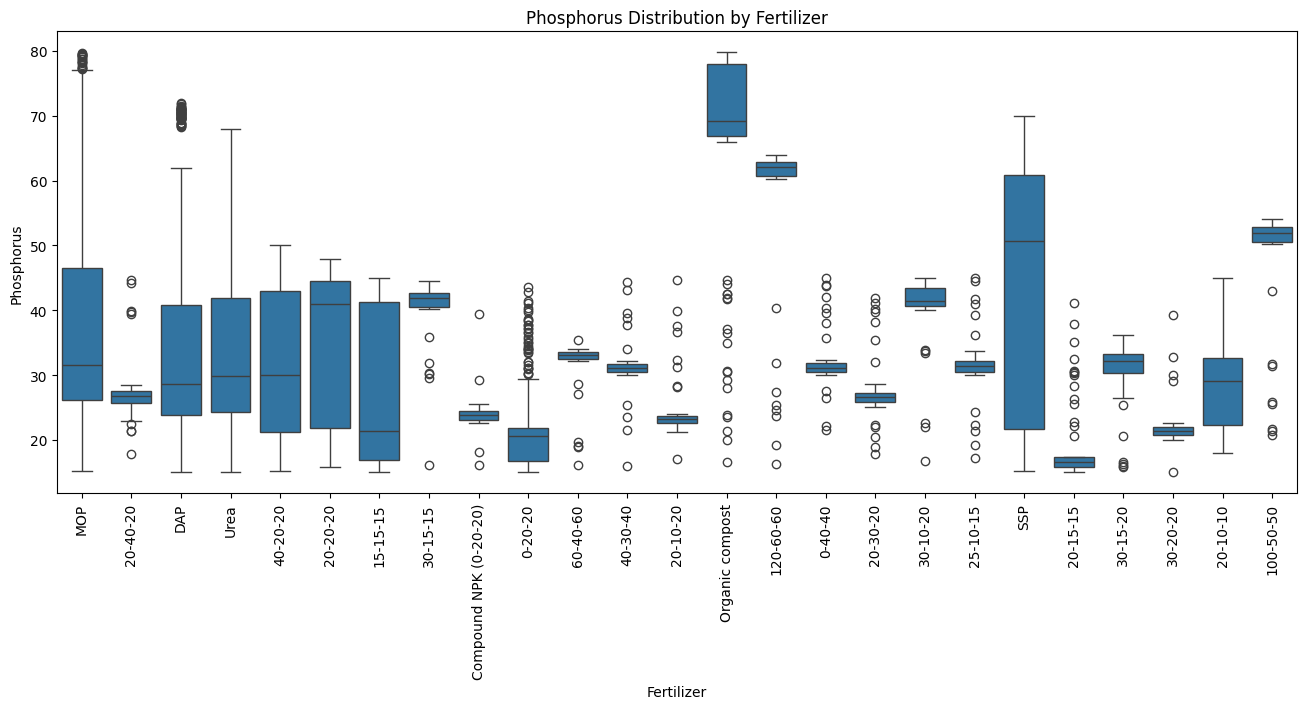

In [38]:
for col in num_cols:
    plt.figure(figsize=(16, 6))
    sns.boxplot(x="Fertilizer", y=col, data=df)
    plt.xticks(rotation=90)
    plt.title(f"{col} Distribution by Fertilizer")
    plt.xlabel("Fertilizer")
    plt.ylabel(col)
    plt.show()

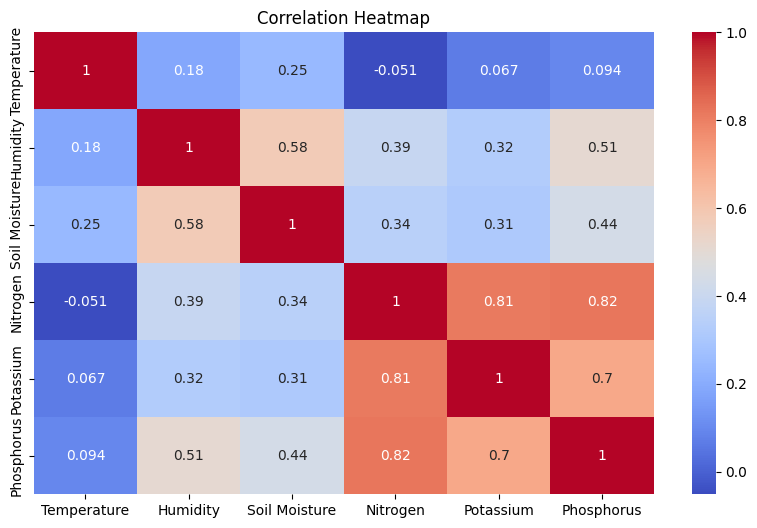

In [41]:
corr = df[num_cols].corr()

plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

# Data Preprocessing

In [42]:
text_cols = ["Soil Type", "Crop Type", "Fertilizer"]

for col in text_cols:
    df[col] = df[col].astype(str).str.strip()

In [48]:
print("Soil Types:")
print(df["Soil Type"].unique())

print("Crop Types:")
print(df["Crop Type"].unique())

print("Fertilizers:")
print(df["Fertilizer"].unique())

Soil Types:
['Sandy Loam' 'Loamy' 'Sand' 'Clay Loam' 'Clay' 'Sandy' 'Loamy Sand'
 'Loam' 'Red Clay Loam' 'Red Loam' 'Silty Loam' 'Alluvial' 'Black Soil']
Crop Types:
['Arhar/Tur' 'Bajra' 'Barley' 'Coriander' 'Cotton (Lint)' 'Cowpea (Lobia)'
 'Dry Chillies' 'Garlic' 'Ginger' 'Gram (Chickpea)' 'Groundnut' 'Jowar'
 'Linseed (Flax)' 'Maize (Grain)' 'Maize (Fodder)' 'Masoor (Red Lentil)'
 'Moong (Green Gram)' 'Onion' 'Peas & Beans (Pulses)' 'Potato'
 'Ragi (Finger Millet)' 'Rapeseed & Mustard' 'Rice' 'Safflower'
 'Sugarcane' 'Sunflower' 'Turmeric' 'Urad (Black Gram)' 'Urad Bean'
 'Wheat']
Fertilizers:
['MOP' '20-40-20' 'DAP' 'Urea' '40-20-20' '20-20-20' '15-15-15' '30-15-15'
 'Compound NPK (0-20-20)' '0-20-20' '60-40-60' '40-30-40' '20-10-20'
 'Organic compost' '120-60-60' '0-40-40' '20-30-20' '30-10-20' '25-10-15'
 'SSP' '20-15-15' '30-15-20' '30-20-20' '20-10-10' '100-50-50']


In [49]:
print("Soil Types:")
print(df["Soil Type"].nunique())

print("Crop Types:")
print(df["Crop Type"].nunique())

print("Fertilizers:")
print(df["Fertilizer"].nunique())

Soil Types:
13
Crop Types:
30
Fertilizers:
25


In [61]:
X = df.drop("Fertilizer", axis=1)
y = df["Fertilizer"]

In [62]:
soil_encoder = LabelEncoder()
crop_encoder = LabelEncoder()

X["Soil Type"] = soil_encoder.fit_transform(X["Soil Type"])
X["Crop Type"] = crop_encoder.fit_transform(X["Crop Type"])



In [63]:
soil_mapping = dict(zip(soil_encoder.classes_, soil_encoder.transform(soil_encoder.classes_)))
crop_mapping = dict(zip(crop_encoder.classes_, crop_encoder.transform(crop_encoder.classes_)))

print("Soil Type Mapping:")
print("-" * 40)

for soil, encoded_value in soil_mapping.items():
    print(f"{soil:<30} → {int(encoded_value)}")


print("\nCrop Type Mapping:")
print("-" * 40)

for crop, encoded_value in crop_mapping.items():
    print(f"{crop:<30} → {int(encoded_value)}")

Soil Type Mapping:
----------------------------------------
Alluvial                       → 0
Black Soil                     → 1
Clay                           → 2
Clay Loam                      → 3
Loam                           → 4
Loamy                          → 5
Loamy Sand                     → 6
Red Clay Loam                  → 7
Red Loam                       → 8
Sand                           → 9
Sandy                          → 10
Sandy Loam                     → 11
Silty Loam                     → 12

Crop Type Mapping:
----------------------------------------
Arhar/Tur                      → 0
Bajra                          → 1
Barley                         → 2
Coriander                      → 3
Cotton (Lint)                  → 4
Cowpea (Lobia)                 → 5
Dry Chillies                   → 6
Garlic                         → 7
Ginger                         → 8
Gram (Chickpea)                → 9
Groundnut                      → 10
Jowar                          → 11

In [52]:
fertilizer_encoder = LabelEncoder()

y_encoded = fertilizer_encoder.fit_transform(y)

In [54]:
fertilizer_mapping = dict(zip(
    fertilizer_encoder.classes_,
    fertilizer_encoder.transform(fertilizer_encoder.classes_)
))

for fertilizer, encoded_value in fertilizer_mapping.items():
    print(f"{fertilizer}  →  {int(encoded_value)}")

0-20-20  →  0
0-40-40  →  1
100-50-50  →  2
120-60-60  →  3
15-15-15  →  4
20-10-10  →  5
20-10-20  →  6
20-15-15  →  7
20-20-20  →  8
20-30-20  →  9
20-40-20  →  10
25-10-15  →  11
30-10-20  →  12
30-15-15  →  13
30-15-20  →  14
30-20-20  →  15
40-20-20  →  16
40-30-40  →  17
60-40-60  →  18
Compound NPK (0-20-20)  →  19
DAP  →  20
MOP  →  21
Organic compost  →  22
SSP  →  23
Urea  →  24


In [64]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

In [65]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (6826, 8)
X_test: (1707, 8)
y_train: (6826,)
y_test: (1707,)


In [67]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [69]:
from sklearn.model_selection import StratifiedKFold
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [71]:
from sklearn.model_selection import cross_val_score

lr = LogisticRegression(
    max_iter=5000,
    class_weight="balanced",
    random_state=42
)

lr_cv_scores = cross_val_score(
    lr,
    X_train_scaled,
    y_train,
    cv=cv,
    scoring="accuracy"
)

lr.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'lbfgs'
,max_iter,5000
,multi_class,'deprecated'


In [72]:
y_train_pred_lr = lr.predict(X_train_scaled)

y_pred_lr = lr.predict(X_test_scaled)

lr_train_accuracy = accuracy_score(y_train, y_train_pred_lr)
lr_test_accuracy = accuracy_score(y_test, y_pred_lr)

print("Logistic Regression Training Accuracy:", lr_train_accuracy)
print("Logistic Regression Test Accuracy:", lr_test_accuracy)

print("Logistic Regression CV Scores:", lr_cv_scores)
print("Logistic Regression Mean CV Accuracy:", lr_cv_scores.mean())
print("Logistic Regression CV Std:", lr_cv_scores.std())

Logistic Regression Training Accuracy: 0.25183123351889836
Logistic Regression Test Accuracy: 0.2630345635618043
Logistic Regression CV Scores: [0.25256223 0.25128205 0.24175824 0.24761905 0.25054945]
Logistic Regression Mean CV Accuracy: 0.24875420333692663
Logistic Regression CV Std: 0.003856060614473867


In [73]:
svm = SVC(
    kernel="rbf",
    probability=True,
    class_weight="balanced",
    random_state=42
)

svm_cv_scores = cross_val_score(
    svm,
    X_train_scaled,
    y_train,
    cv=cv,
    scoring="accuracy"
)

svm.fit(X_train_scaled, y_train)


,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,True
,tol,0.001
,cache_size,200
,class_weight,'balanced'
,verbose,False


In [74]:
y_train_pred_svm = svm.predict(X_train_scaled)

y_pred_svm = svm.predict(X_test_scaled)

svm_train_accuracy = accuracy_score(y_train, y_train_pred_svm)
svm_test_accuracy = accuracy_score(y_test, y_pred_svm)

print("SVM Training Accuracy:", svm_train_accuracy)
print("SVM Test Accuracy:", svm_test_accuracy)
print("SVM CV Scores:", svm_cv_scores)
print("SVM Mean CV Accuracy:", svm_cv_scores.mean())
print("SVM CV Std:", svm_cv_scores.std())

SVM Training Accuracy: 0.5440961031350717
SVM Test Accuracy: 0.5442296426479203
SVM CV Scores: [0.51171303 0.48937729 0.51501832 0.5032967  0.49157509]
SVM Mean CV Accuracy: 0.5021960860028211
SVM CV Std: 0.0103278286408337


In [75]:
dt = DecisionTreeClassifier(
    random_state=42,
    class_weight="balanced"
)

dt_cv_scores = cross_val_score(
    dt,
    X_train_scaled,
    y_train,
    cv=cv,
    scoring="accuracy"
)

dt.fit(X_train_scaled, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,'balanced'


In [76]:
y_train_pred_dt = dt.predict(X_train_scaled)

y_pred_dt = dt.predict(X_test_scaled)

dt_train_accuracy = accuracy_score(y_train, y_train_pred_dt)
dt_test_accuracy = accuracy_score(y_test, y_pred_dt)

print("Decision Tree Training Accuracy:", dt_train_accuracy)
print("Decision Tree Test Accuracy:", dt_test_accuracy)
print("Decision Tree CV Scores:", dt_cv_scores)
print("Decision Tree Mean CV Accuracy:", dt_cv_scores.mean())
print("Decision Tree CV Std:", dt_cv_scores.std())

Decision Tree Training Accuracy: 1.0
Decision Tree Test Accuracy: 0.8781487990626831
Decision Tree CV Scores: [0.8704246  0.85421245 0.87106227 0.85567766 0.87252747]
Decision Tree Mean CV Accuracy: 0.8647808901688844
Decision Tree CV Std: 0.008073133615198853


In [78]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)

rf_cv_scores = cross_val_score(
    rf,
    X_train_scaled,
    y_train,
    cv=cv,
    scoring="accuracy"
)

rf.fit(X_train_scaled, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [79]:
y_train_pred_rf = rf.predict(X_train_scaled)

y_pred_rf = rf.predict(X_test_scaled)


rf_train_accuracy = accuracy_score(y_train, y_train_pred_rf)
rf_test_accuracy = accuracy_score(y_test, y_pred_rf)

print("Random Forest Training Accuracy:", rf_train_accuracy)
print("Random Forest Test Accuracy:", rf_test_accuracy)
print("Random Forest CV Scores:", rf_cv_scores)
print("Random Forest Mean CV Accuracy:", rf_cv_scores.mean())
print("Random Forest CV Std:", rf_cv_scores.std())

Random Forest Training Accuracy: 1.0
Random Forest Test Accuracy: 0.8945518453427065
Random Forest CV Scores: [0.8806735  0.86593407 0.87252747 0.86373626 0.88791209]
Random Forest Mean CV Accuracy: 0.8741566778755651
Random Forest CV Std: 0.009061246651252988


In [80]:
!pip install xgboost

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [82]:
from xgboost import XGBClassifier
xgb = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=5,
    objective="multi:softmax",
    eval_metric="mlogloss",
    random_state=42
)

xgb_cv_scores = cross_val_score(
    xgb,
    X_train_scaled,
    y_train,
    cv=cv,
    scoring="accuracy"
)

xgb.fit(X_train_scaled, y_train)

,objective,'multi:softmax'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'mlogloss'


In [83]:
y_train_pred_xgb = xgb.predict(X_train_scaled)

y_pred_xgb = xgb.predict(X_test_scaled)

xgb_train_accuracy = accuracy_score(y_train, y_train_pred_xgb)
xgb_test_accuracy = accuracy_score(y_test, y_pred_xgb)

print("XGBoost Training Accuracy:", xgb_train_accuracy)
print("XGBoost Test Accuracy:", xgb_test_accuracy)
print("XGBoost CV Scores:", xgb_cv_scores)
print("XGBoost Mean CV Accuracy:", xgb_cv_scores.mean())
print("XGBoost CV Std:", xgb_cv_scores.std())

XGBoost Training Accuracy: 0.995605039554644
XGBoost Test Accuracy: 0.8910369068541301
XGBoost CV Scores: [0.8806735  0.87032967 0.87985348 0.87106227 0.89304029]
XGBoost Mean CV Accuracy: 0.87899184271073
XGBoost CV Std: 0.008232140437232544


In [84]:
model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "SVM",
        "Decision Tree",
        "Random Forest",
        "XGBoost"
    ],
    "Training Accuracy": [
        lr_train_accuracy,
        svm_train_accuracy,
        dt_train_accuracy,
        rf_train_accuracy,
        xgb_train_accuracy
    ],
    "Mean CV Accuracy": [
        lr_cv_scores.mean(),
        svm_cv_scores.mean(),
        dt_cv_scores.mean(),
        rf_cv_scores.mean(),
        xgb_cv_scores.mean()
    ],
    "CV Standard Deviation": [
        lr_cv_scores.std(),
        svm_cv_scores.std(),
        dt_cv_scores.std(),
        rf_cv_scores.std(),
        xgb_cv_scores.std()
    ],
    "Test Accuracy": [
        lr_test_accuracy,
        svm_test_accuracy,
        dt_test_accuracy,
        rf_test_accuracy,
        xgb_test_accuracy
    ]
})

model_comparison = model_comparison.sort_values(
    by="Test Accuracy",
    ascending=False
)

model_comparison

,Model,Training Accuracy,Mean CV Accuracy,CV Standard Deviation,Test Accuracy
3,Random Forest,1.000000,0.874157,0.009061,0.894552
4,XGBoost,0.995605,0.878992,0.008232,0.891037
2,Decision Tree,1.000000,0.864781,0.008073,0.878149
1,SVM,0.544096,0.502196,0.010328,0.544230
0,Logistic Regression,0.251831,0.248754,0.003856,0.263035


# Trying Hyperparameter Tunning

In [85]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import accuracy_score

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

rf_tuned = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    min_samples_split=10,
    min_samples_leaf=4,
    max_features="sqrt",
    class_weight="balanced",
    random_state=42
)

rf_tuned_cv_scores = cross_val_score(
    rf_tuned,
    X_train_scaled,
    y_train,
    cv=cv,
    scoring="accuracy"
)

print("Tuned Random Forest CV Scores:", rf_tuned_cv_scores)
print("Tuned Random Forest Mean CV Accuracy:", rf_tuned_cv_scores.mean())
print("Tuned Random Forest CV Std:", rf_tuned_cv_scores.std())

rf_tuned.fit(X_train_scaled, y_train)

y_train_pred_rf_tuned = rf_tuned.predict(X_train_scaled)
y_pred_rf_tuned = rf_tuned.predict(X_test_scaled)

rf_tuned_train_accuracy = accuracy_score(y_train, y_train_pred_rf_tuned)
rf_tuned_test_accuracy = accuracy_score(y_test, y_pred_rf_tuned)

print("Tuned Random Forest Training Accuracy:", rf_tuned_train_accuracy)
print("Tuned Random Forest Test Accuracy:", rf_tuned_test_accuracy)

Tuned Random Forest CV Scores: [0.87481698 0.86593407 0.86813187 0.86227106 0.87326007]
Tuned Random Forest Mean CV Accuracy: 0.8688828106983305
Tuned Random Forest CV Std: 0.004633552994105909
Tuned Random Forest Training Accuracy: 0.9225021974802227
Tuned Random Forest Test Accuracy: 0.8793204452255419


In [88]:
rf_tuned_2 = RandomForestClassifier(
    n_estimators=300,
    max_depth=16,
    min_samples_split=6,
    min_samples_leaf=2,
    max_features="sqrt",
    class_weight="balanced",
    random_state=42
)

rf_tuned_2_cv_scores = cross_val_score(
    rf_tuned_2,
    X_train_scaled,
    y_train,
    cv=cv,
    scoring="accuracy"
)

print("Tuned RF 2 CV Scores:", rf_tuned_2_cv_scores)
print("Tuned RF 2 Mean CV Accuracy:", rf_tuned_2_cv_scores.mean())
print("Tuned RF 2 CV Std:", rf_tuned_2_cv_scores.std())

rf_tuned_2.fit(X_train_scaled, y_train)

y_train_pred_rf_tuned_2 = rf_tuned_2.predict(X_train_scaled)
y_pred_rf_tuned_2 = rf_tuned_2.predict(X_test_scaled)

rf_tuned_2_train_accuracy = accuracy_score(y_train, y_train_pred_rf_tuned_2)
rf_tuned_2_test_accuracy = accuracy_score(y_test, y_pred_rf_tuned_2)

print("Tuned RF 2 Training Accuracy:", rf_tuned_2_train_accuracy)
print("Tuned RF 2 Test Accuracy:", rf_tuned_2_test_accuracy)

Tuned RF 2 CV Scores: [0.87994143 0.86520147 0.87179487 0.86080586 0.87765568]
Tuned RF 2 Mean CV Accuracy: 0.8710798620608283
Tuned RF 2 CV Std: 0.007244179916486094
Tuned RF 2 Training Accuracy: 0.9866686199824202
Tuned RF 2 Test Accuracy: 0.8863503222026948


In [91]:
# Final selected model
final_model = rf

# Final predictions
y_train_pred_final = final_model.predict(X_train_scaled)
y_test_pred_final = final_model.predict(X_test_scaled)

In [92]:
train_accuracy = accuracy_score(y_train, y_train_pred_final)
test_accuracy = accuracy_score(y_test, y_test_pred_final)

print("Final Model: Random Forest")
print("Training Accuracy:", train_accuracy)
print("Test Accuracy:", test_accuracy)

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_test_pred_final,
    target_names=fertilizer_encoder.classes_
))

Final Model: Random Forest
Training Accuracy: 1.0
Test Accuracy: 0.8945518453427065

Classification Report:
                        precision    recall  f1-score   support

               0-20-20       0.99      0.87      0.92        98
               0-40-40       1.00      0.79      0.88        14
             100-50-50       1.00      0.82      0.90        11
             120-60-60       1.00      0.91      0.95        11
              15-15-15       0.97      0.88      0.92        40
              20-10-10       0.90      1.00      0.95        28
              20-10-20       1.00      0.75      0.86        12
              20-15-15       1.00      0.87      0.93        15
              20-20-20       0.94      0.85      0.89        40
              20-30-20       1.00      0.87      0.93        15
              20-40-20       1.00      0.84      0.91        19
              25-10-15       1.00      0.87      0.93        15
              30-10-20       1.00      0.93      0.96      

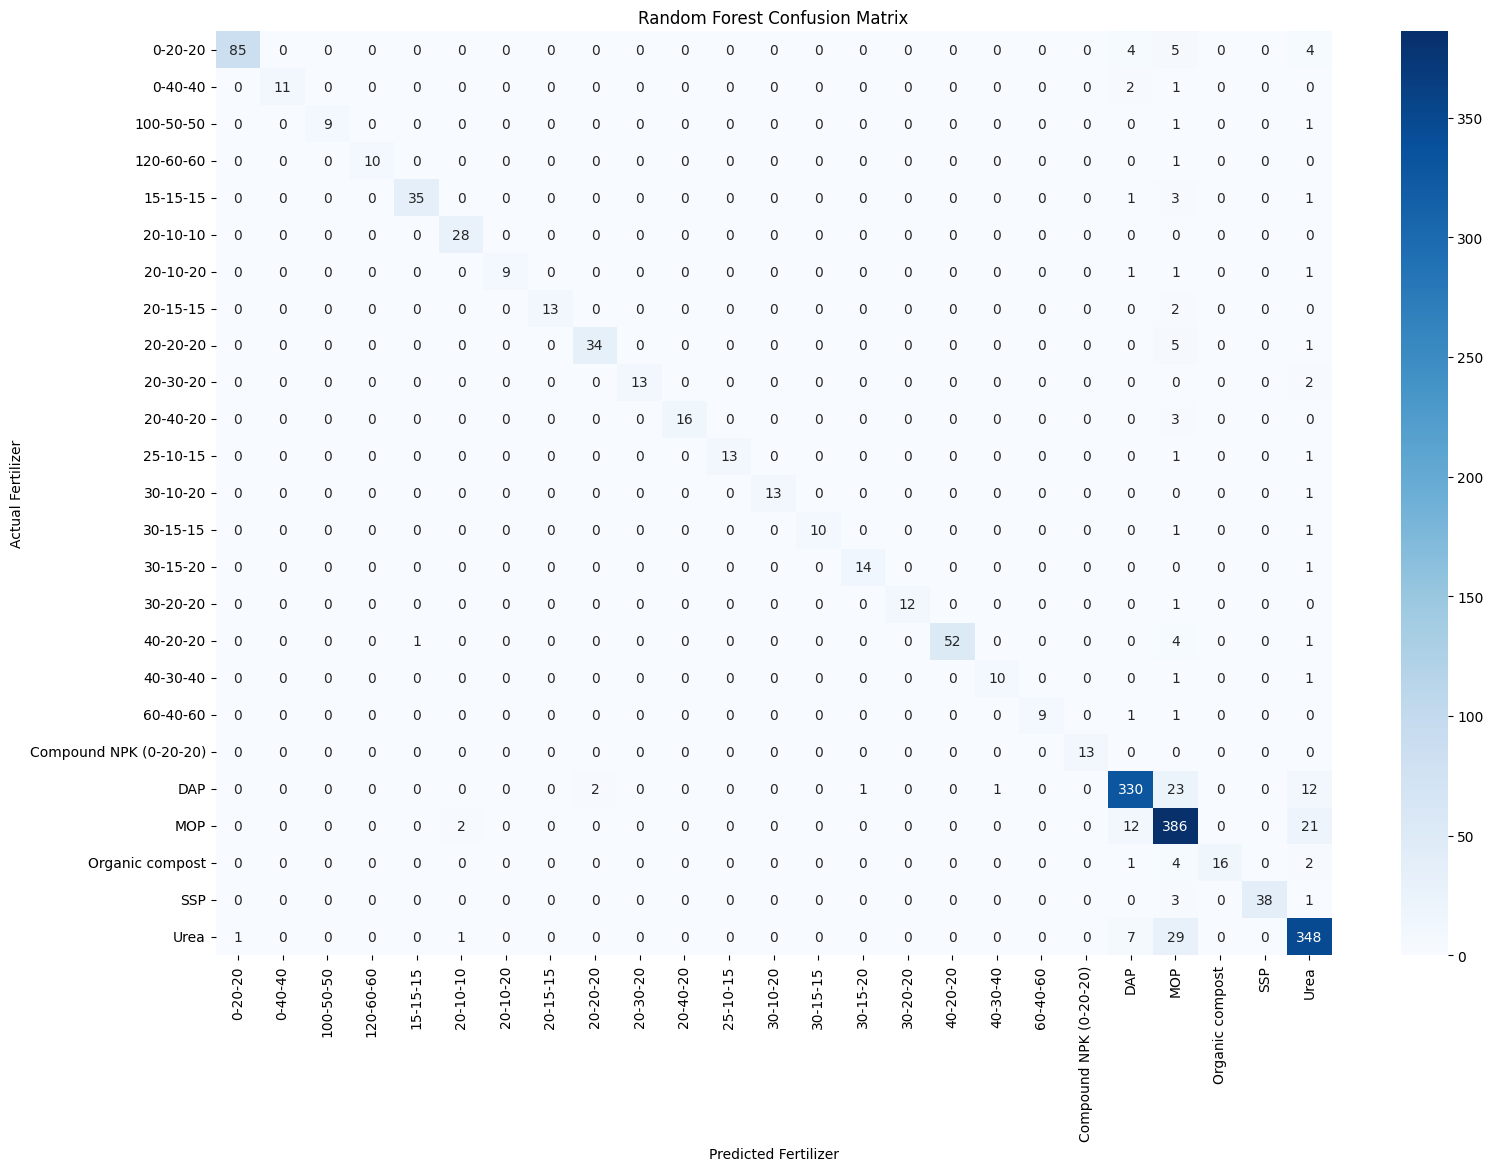

In [93]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_test_pred_final)

plt.figure(figsize=(18, 12))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=fertilizer_encoder.classes_,
    yticklabels=fertilizer_encoder.classes_
)

plt.xlabel("Predicted Fertilizer")
plt.ylabel("Actual Fertilizer")
plt.title("Random Forest Confusion Matrix")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.show()

In [94]:
print("Soil Types:")
print(soil_encoder.classes_)

print("\nCrop Types:")
print(crop_encoder.classes_)

Soil Types:
['Alluvial' 'Black Soil' 'Clay' 'Clay Loam' 'Loam' 'Loamy' 'Loamy Sand'
 'Red Clay Loam' 'Red Loam' 'Sand' 'Sandy' 'Sandy Loam' 'Silty Loam']

Crop Types:
['Arhar/Tur' 'Bajra' 'Barley' 'Coriander' 'Cotton (Lint)' 'Cowpea (Lobia)'
 'Dry Chillies' 'Garlic' 'Ginger' 'Gram (Chickpea)' 'Groundnut' 'Jowar'
 'Linseed (Flax)' 'Maize (Fodder)' 'Maize (Grain)' 'Masoor (Red Lentil)'
 'Moong (Green Gram)' 'Onion' 'Peas & Beans (Pulses)' 'Potato'
 'Ragi (Finger Millet)' 'Rapeseed & Mustard' 'Rice' 'Safflower'
 'Sugarcane' 'Sunflower' 'Turmeric' 'Urad (Black Gram)' 'Urad Bean'
 'Wheat']


In [95]:
import pandas as pd

sample_input = pd.DataFrame([{
    "Temperature": 26.0,
    "Humidity": 55.0,
    "Soil Moisture": 25.0,
    "Soil Type": soil_encoder.transform(["Sandy Loam"])[0],
    "Crop Type": crop_encoder.transform(["Arhar/Tur"])[0],
    "Nitrogen": 40.0,
    "Potassium": 30.0,
    "Phosphorus": 35.0
}])

sample_input_scaled = scaler.transform(sample_input)

sample_prediction = final_model.predict(sample_input_scaled)

recommended_fertilizer = fertilizer_encoder.inverse_transform(sample_prediction)

print("Recommended Fertilizer:", recommended_fertilizer[0])

Recommended Fertilizer: DAP


# Saving Model

In [97]:
import pickle

with open("fertilizer_model.pkl", "wb") as f:
    pickle.dump(final_model, f)

with open("fertilizer_scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

with open("soil_encoder.pkl", "wb") as f:
    pickle.dump(soil_encoder, f)

with open("crop_encoder.pkl", "wb") as f:
    pickle.dump(crop_encoder, f)

with open("fertilizer_encoder.pkl", "wb") as f:
    pickle.dump(fertilizer_encoder, f)

print("Files saved successfully in current folder!")

Files saved successfully in current folder!
